In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
df = pd.read_csv("student-mat.csv", sep=";")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 395
Columns: 33


In [3]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [5]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    str  
 1   sex         395 non-null    str  
 2   age         395 non-null    int64
 3   address     395 non-null    str  
 4   famsize     395 non-null    str  
 5   Pstatus     395 non-null    str  
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    str  
 9   Fjob        395 non-null    str  
 10  reason      395 non-null    str  
 11  guardian    395 non-null    str  
 12  traveltime  395 non-null    int64
 13  studytime   395 non-null    int64
 14  failures    395 non-null    int64
 15  schoolsup   395 non-null    str  
 16  famsup      395 non-null    str  
 17  paid        395 non-null    str  
 18  activities  395 non-null    str  
 19  nursery     395 non-null    str  
 20  higher      395 non-null    str  
 21  inte

In [6]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


In [7]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [8]:
df["pass"] = (df["G3"] >= 10).astype(int)

print(df["pass"].value_counts())

print("\n0 = Fail")
print("1 = Pass")

pass
1    265
0    130
Name: count, dtype: int64

0 = Fail
1 = Pass


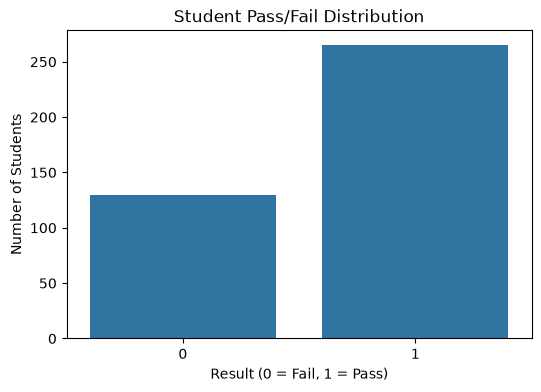

In [9]:
plt.figure(figsize=(6,4))

sns.countplot(x="pass", data=df)

plt.title("Student Pass/Fail Distribution")
plt.xlabel("Result (0 = Fail, 1 = Pass)")
plt.ylabel("Number of Students")

plt.show()

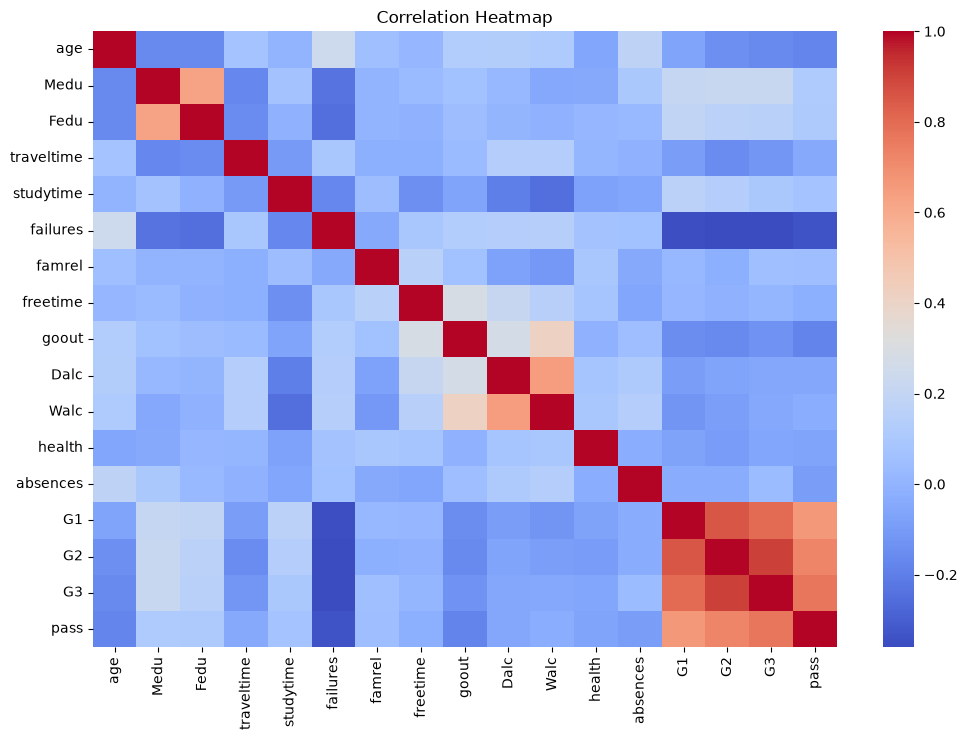

In [10]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(12,8))

sns.heatmap(numeric_df.corr(), cmap="coolwarm", annot=False)

plt.title("Correlation Heatmap")

plt.show()

In [11]:
X = df.drop(columns=["G3", "pass"])
y = df["pass"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (395, 32)
Target: (395,)


In [12]:
X = pd.get_dummies(X, drop_first=True)

print("Encoded feature shape:", X.shape)

Encoded feature shape: (395, 41)


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (316, 41)
Testing data: (79, 41)


In [14]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [15]:
logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train_scaled, y_train)

y_pred_logistic = logistic_model.predict(X_test_scaled)

logistic_accuracy = accuracy_score(y_test, y_pred_logistic)

print("Logistic Regression Accuracy:",
      round(logistic_accuracy * 100, 2), "%")

Logistic Regression Accuracy: 84.81 %


In [16]:
print(classification_report(y_test, y_pred_logistic))

              precision    recall  f1-score   support

           0       0.72      0.88      0.79        26
           1       0.94      0.83      0.88        53

    accuracy                           0.85        79
   macro avg       0.83      0.86      0.84        79
weighted avg       0.86      0.85      0.85        79



In [17]:
tree_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

tree_accuracy = accuracy_score(y_test, y_pred_tree)

print("Decision Tree Accuracy:",
      round(tree_accuracy * 100, 2), "%")

Decision Tree Accuracy: 86.08 %


In [18]:
forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

forest_model.fit(X_train, y_train)

y_pred_forest = forest_model.predict(X_test)

forest_accuracy = accuracy_score(y_test, y_pred_forest)

print("Random Forest Accuracy:",
      round(forest_accuracy * 100, 2), "%")

Random Forest Accuracy: 87.34 %


In [19]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        logistic_accuracy,
        tree_accuracy,
        forest_accuracy
    ]
})

results["Accuracy (%)"] = results["Accuracy"] * 100

results

,Model,Accuracy,Accuracy (%)
0,Logistic Regression,0.848101,84.810127
1,Decision Tree,0.860759,86.075949
2,Random Forest,0.873418,87.341772


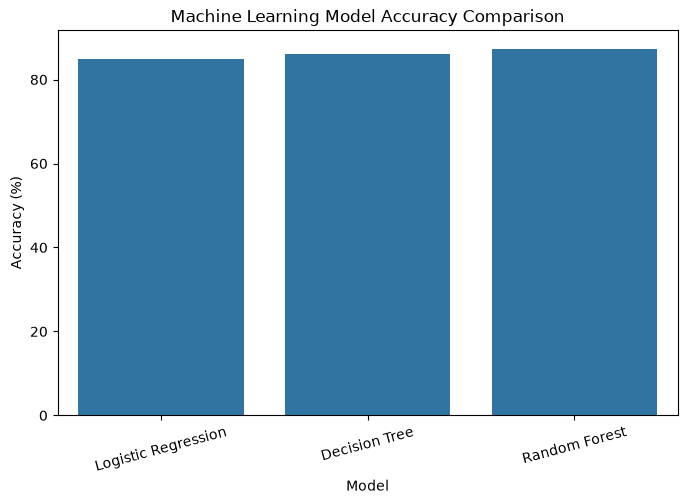

In [20]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Model",
    y="Accuracy (%)",
    data=results
)

plt.title("Machine Learning Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=15)

plt.show()

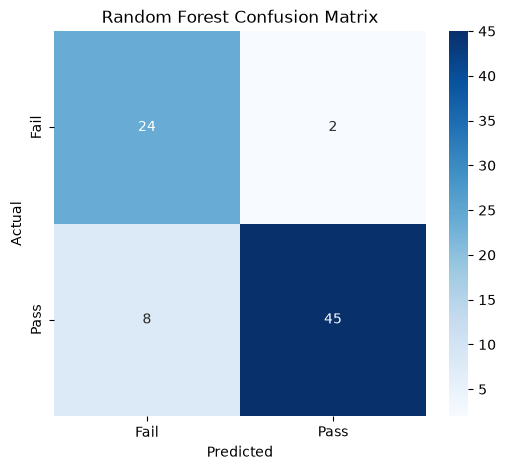

In [21]:
cm = confusion_matrix(y_test, y_pred_forest)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fail", "Pass"],
    yticklabels=["Fail", "Pass"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

In [22]:
print("Random Forest Classification Report:")
print(classification_report(
    y_test,
    y_pred_forest,
    target_names=["Fail", "Pass"]
))

Random Forest Classification Report:
              precision    recall  f1-score   support

        Fail       0.75      0.92      0.83        26
        Pass       0.96      0.85      0.90        53

    accuracy                           0.87        79
   macro avg       0.85      0.89      0.86        79
weighted avg       0.89      0.87      0.88        79



In [23]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": forest_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(15)

,Feature,Importance
14,G2,0.357823
13,G1,0.198104
5,failures,0.043452
12,absences,0.038176
8,goout,0.027756
0,age,0.025072
10,Walc,0.019552
11,health,0.017870
1,Medu,0.016358
2,Fedu,0.016341


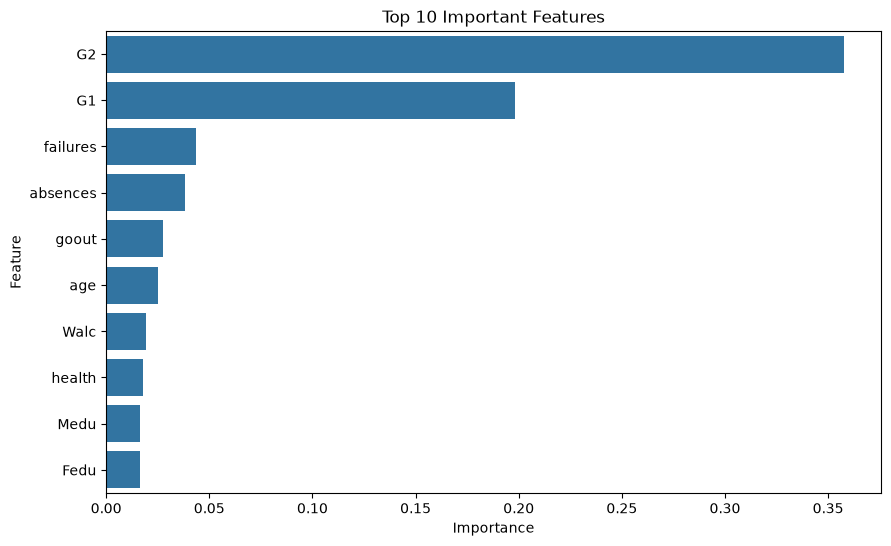

In [24]:
top_features = importance.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=top_features
)

plt.title("Top 10 Important Features")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [25]:
sample_student = X_test.iloc[[0]]

prediction = forest_model.predict(sample_student)[0]

if prediction == 1:
    print("Prediction: PASS")
else:
    print("Prediction: FAIL")

Prediction: PASS


In [26]:
print("===== FINAL MODEL RESULTS =====")

for index, row in results.iterrows():
    print(
        row["Model"],
        "->",
        round(row["Accuracy (%)"], 2),
        "%"
    )

===== FINAL MODEL RESULTS =====
Logistic Regression -> 84.81 %
Decision Tree -> 86.08 %
Random Forest -> 87.34 %
